In [1]:
#Day-1 
import sys
print(sys.version)

3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import wandb

In [2]:
import random
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [8]:
!pip install wandb

  Using cached wandb-0.23.0-py3-none-win_amd64.whl.metadata (12 kB)
  Using cached sentry_sdk-2.45.0-py2.py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
    --------------------------------------- 0.3/19.4 MB ? eta -:--:--
   -- ------------------------------------- 1.0/19.4 MB 3.6 MB/s eta 0:00:06
   ----- ---------------------------------- 2.9/19.4 MB 5.8 MB/s eta 0:00:03
   -------- ------------------------------- 4.2/19.4 MB 6.3 MB/s eta 0:00:03
   ---------- ----------------------------- 5.2/19.4 MB 5.9 MB/s eta 0:00:03
   ----------- ---------------------------- 5.8/19.4 MB 5.5 MB/s eta 0:00:03
   ------------ --------------------------- 6.3/19.4 MB 4.6 MB/s eta 0:00:03
   ------------- -------------------------- 6.6/19.4 MB 4.4 MB/s eta 0:00:03
   -------------- ------------------------- 7.1/19.4 MB 4.0 MB/s eta 0:00:04
   --------------- ------------------------ 7.3/19.4 MB 3.8 MB/s eta 0:00:04
   ---------------- --------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!wandb login

wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
# Reading the dataset

In [5]:
df = pd.read_csv('telco-customer-churn-by-IBM.csv')

In [6]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
!pip install pandera

In [11]:
import pandera.pandas as pa
from pandera import Column, Check

# Define schema
schema = pa.DataFrameSchema({
    "customerID": Column(pa.String, nullable=False),
    "gender": Column(pa.String, checks=Check.isin(["Male", "Female"]), nullable=False),
    "SeniorCitizen": Column(pa.Int, checks=Check.isin([0,1]), nullable=False),
    "Partner": Column(pa.String, checks=Check.isin(["Yes","No"]), nullable=False),
    "Dependents": Column(pa.String, checks=Check.isin(["Yes","No"]), nullable=False),
    "tenure": Column(pa.Int, checks=Check.ge(0), nullable=False),
    "PhoneService": Column(pa.String, checks=Check.isin(["Yes","No"]), nullable=False),
    "MultipleLines": Column(pa.String, checks=Check.isin(["Yes","No","No phone service"]), nullable=False),
    "InternetService": Column(pa.String, checks=Check.isin(["DSL","Fiber optic","No"]), nullable=False),
    "OnlineSecurity": Column(pa.String, checks=Check.isin(["Yes","No","No internet service"]), nullable=False),
    "OnlineBackup": Column(pa.String, checks=Check.isin(["Yes","No","No internet service"]), nullable=False),
    "DeviceProtection": Column(pa.String, checks=Check.isin(["Yes","No","No internet service"]), nullable=False),
    "TechSupport": Column(pa.String, checks=Check.isin(["Yes","No","No internet service"]), nullable=False),
    "StreamingTV": Column(pa.String, checks=Check.isin(["Yes","No","No internet service"]), nullable=False),
    "StreamingMovies": Column(pa.String, checks=Check.isin(["Yes","No","No internet service"]), nullable=False),
    "Contract": Column(pa.String, checks=Check.isin(["Month-to-month","One year","Two year"]), nullable=False),
    "PaperlessBilling": Column(pa.String, checks=Check.isin(["Yes","No"]), nullable=False),
    "PaymentMethod": Column(pa.String, checks=Check.isin([
        "Electronic check", 
        "Mailed check", 
        "Bank transfer (automatic)", 
        "Credit card (automatic)"
    ]), nullable=False),
    "MonthlyCharges": Column(pa.Float, checks=Check.ge(0), nullable=False),
    "TotalCharges": Column(pa.String, nullable=False),  # will convert to numeric later
    "Churn": Column(pa.String, checks=Check.isin(["Yes","No"]), nullable=False)
})

# Validate the dataframe
validated_df = schema.validate(df, lazy=True)  # lazy=True shows all errors at once

In [9]:
import hashlib
import os
import wandb

# Function to compute MD5

def md5_checksum(file_path):
    """Compute MD5 checksum of a file."""
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:  # binary mode
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()


# Directory with datasets

data_dir = r"C:\Users\Hp\Frost Digital Ventures\Week-2" 
dataset_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".csv")]

# Compute checksums

checksums = {}
for file in dataset_files:
    file_name = os.path.basename(file)
    checksums[file_name] = md5_checksum(file)
    print(f"{file_name}: {checksums[file_name]}")


# Log to W&B

wandb.init(project="Week-2", name="Dataset_MD5_Checksums")
for file_name, checksum in checksums.items():
    wandb.log({f"MD5_{file_name}": checksum})
wandb.finish()

telco-customer-churn-by-IBM.csv: 0f9de68e012bd3aed5fa7cdc9fc421af


wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


MD5_telco-customer-churn-by-IBM.csv,0f9de68e012bd3aed5fa...


In [8]:
df['Churn'].value_counts() # class imbalance.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
# Churn : yes=1 & no=0
# Business Cost : cost_fn = 5 (missing a churn is 5 times worse) & cost_fp = 1

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# dropped the customerID column - no use of it as a feature
df=df.drop('customerID',axis=1)

In [12]:
df.shape

(7043, 20)

In [13]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
# Stratified Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn'].map({"Yes":1,"No":0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

In [16]:
# Leakage Audit

In [17]:
X_train.shape

(5634, 19)

In [18]:
y_train.shape

(5634,)

In [19]:
X_test.shape

(1409, 19)

In [20]:
y_test.shape

(1409,)

In [21]:
# Data Lekeage prevented by doing train test split with straify=y with straification in case of imbalanced dataset

In [22]:
# Quick EDA

X_train.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [23]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [24]:
y_test.value_counts(normalize=True)

Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 
 1

In [26]:
X_train['TotalCharges'] =pd.to_numeric(X_train['TotalCharges'],errors='coerce')

In [27]:
X_test["TotalCharges"] = pd.to_numeric(X_test["TotalCharges"], errors="coerce")

In [28]:
X_train.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
dtype: int64

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [ ]:
X_train.info()

In [30]:
# numerical features
numerical_features = ["tenure","MonthlyCharges","TotalCharges"]

# categorical features
categorical_features = [col for col in X_train.columns if col not in numerical_features]

# numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', cat_pipeline, categorical_features)
])

# fit only on training data
preprocessor.fit(X_train)

# transform train and test sets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get one-hot encoded feature names
cat_features = preprocessor.named_transformers_['cat']\
    .named_steps['onehot']\
    .get_feature_names_out(categorical_features)

all_features = np.concatenate([numerical_features, cat_features])

X_train_processed = pd.DataFrame(X_train_processed, columns=all_features, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_features, index=X_test.index)

In [31]:
X_test_processed.isnull().sum()

tenure                                     0
MonthlyCharges                             0
TotalCharges                               0
gender_Female                              0
gender_Male                                0
SeniorCitizen_0                            0
SeniorCitizen_1                            0
Partner_No                                 0
Partner_Yes                                0
Dependents_No                              0
Dependents_Yes                             0
PhoneService_No                            0
PhoneService_Yes                           0
MultipleLines_No                           0
MultipleLines_No phone service             0
MultipleLines_Yes                          0
InternetService_DSL                        0
InternetService_Fiber optic                0
InternetService_No                         0
OnlineSecurity_No                          0
OnlineSecurity_No internet service         0
OnlineSecurity_Yes                         0
OnlineBack

In [32]:
X_test_processed

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,SeniorCitizen_0,SeniorCitizen_1,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
437,1.608483,1.629976,2.707614,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2280,-0.996684,1.168725,-0.611506,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2235,0.346606,0.445324,0.399490,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4460,-0.589626,0.440347,-0.365546,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3761,1.608483,0.588013,1.588523,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5143,0.672252,0.738999,0.897293,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4439,-0.182569,-1.480980,-0.796173,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3857,-1.118801,-1.469365,-0.969338,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4758,0.957192,-1.500890,-0.548567,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0


In [33]:
# Day-2 

In [34]:
!pip install imbalanced-learn

In [ ]:
import wandb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve,auc,classification_report
from imblearn.over_sampling import SMOTE

In [36]:
# Init WB

wandb.init(
    project="Week-2",
    name="Day2_LogReg_Comparisons",
    config={
        "model": "LogisticRegression",
        "imbalance_methods": ["majority", "vanilla", "class_weight", "smote"],
        "random_seed": 42
    }
)

wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [44]:
y_train.value_counts(normalize=True)

Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

In [38]:
#  MAJORITY BASELINE
majority_class = y_train.value_counts().idxmax()
y_pred_majority = np.full_like(y_test, majority_class)

f1_majority = f1_score(y_test, y_pred_majority)
roc_majority = roc_auc_score(y_test, y_pred_majority)

print("\nMajority Baseline")
print("F1:", f1_majority)
print("ROC-AUC:", roc_majority)
print(classification_report(y_test, y_pred_majority))

wandb.log({
    "Majority/F1": f1_majority,
    "Majority/ROC_AUC": roc_majority
})


Majority Baseline
F1: 0.0
ROC-AUC: 0.5


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



In [39]:
# VANILLA LOGISTIC REGRESSION

lr_vanilla = LogisticRegression(max_iter=2000, random_state=42)
lr_vanilla.fit(X_train_processed, y_train)

y_pred_van = lr_vanilla.predict(X_test_processed)
y_proba_van = lr_vanilla.predict_proba(X_test_processed)[:, 1]

f1_van = f1_score(y_test, y_pred_van)
roc_van = roc_auc_score(y_test, y_proba_van)

print("\nVanilla Logistic Regression")
print("F1:", f1_van)
print("ROC-AUC:", roc_van)
print(classification_report(y_test, y_pred_van))

wandb.log({
    "Vanilla/F1": f1_van,
    "Vanilla/ROC_AUC": roc_van
})


Vanilla Logistic Regression
F1: 0.6040462427745664
ROC-AUC: 0.8418713994161565
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [40]:
# LOGISTIC REGRESSION (CLASS WEIGHT)

lr_bal = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_bal.fit(X_train_processed, y_train)

y_pred_bal = lr_bal.predict(X_test_processed)
y_proba_bal = lr_bal.predict_proba(X_test_processed)[:, 1]

f1_bal = f1_score(y_test, y_pred_bal)
roc_bal = roc_auc_score(y_test, y_proba_bal)

print("\nLogistic Regression (class_weight)")
print("F1:", f1_bal)
print("ROC-AUC:", roc_bal)
print(classification_report(y_test, y_pred_bal))

wandb.log({
    "ClassWeight/F1": f1_bal,
    "ClassWeight/ROC_AUC": roc_bal
})


Logistic Regression (class_weight)
F1: 0.6129707112970711
ROC-AUC: 0.8414063912785139
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [41]:
#  LOGISTIC REGRESSION WITH SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_processed, y_train)

lr_sm = LogisticRegression(max_iter=2000, random_state=42)
lr_sm.fit(X_res, y_res)

y_pred_sm = lr_sm.predict(X_test_processed)
y_proba_sm = lr_sm.predict_proba(X_test_processed)[:, 1]

f1_sm = f1_score(y_test, y_pred_sm)
roc_sm = roc_auc_score(y_test, y_proba_sm)

print("\nLogistic Regression (SMOTE)")
print("F1:", f1_sm)
print("ROC-AUC:", roc_sm)
print(classification_report(y_test, y_pred_sm))

wandb.log({
    "SMOTE/F1": f1_sm,
    "SMOTE/ROC_AUC": roc_sm
})


Logistic Regression (SMOTE)
F1: 0.6163391933815926
ROC-AUC: 0.8397168617117465
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



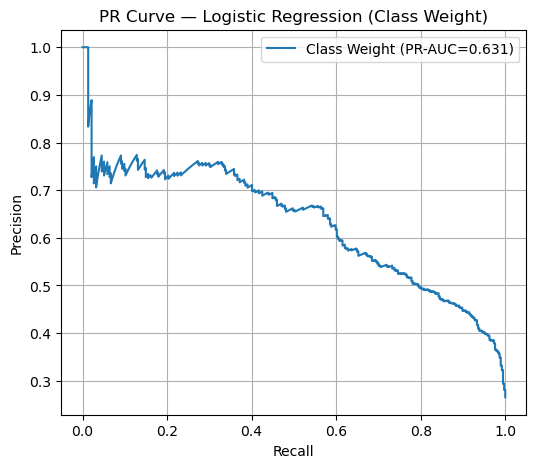

In [42]:
# PR Curve for class weight model

precision_bal, recall_bal, _ = precision_recall_curve(y_test, y_proba_bal)
pr_auc_bal = auc(recall_bal, precision_bal)

fig_bal, ax_bal = plt.subplots(figsize=(6,5))
ax_bal.plot(recall_bal, precision_bal, label=f"Class Weight (PR-AUC={pr_auc_bal:.3f})")
ax_bal.set_xlabel("Recall")
ax_bal.set_ylabel("Precision")
ax_bal.set_title("PR Curve — Logistic Regression (Class Weight)")
ax_bal.legend()
ax_bal.grid(True)

wandb.log({"PR_Curve_ClassWeight": wandb.Image(fig_bal)})
plt.show()

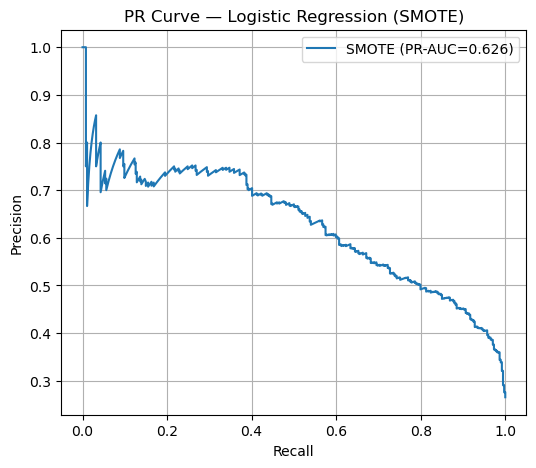

In [43]:
# PR curve for SMOTE

precision_sm, recall_sm, _ = precision_recall_curve(y_test, y_proba_sm)
pr_auc_sm = auc(recall_sm, precision_sm)

fig_sm, ax_sm = plt.subplots(figsize=(6,5))
ax_sm.plot(recall_sm, precision_sm, label=f"SMOTE (PR-AUC={pr_auc_sm:.3f})")
ax_sm.set_xlabel("Recall")
ax_sm.set_ylabel("Precision")
ax_sm.set_title("PR Curve — Logistic Regression (SMOTE)")
ax_sm.legend()
ax_sm.grid(True)

wandb.log({"PR_Curve_SMOTE": wandb.Image(fig_sm)})
plt.show()

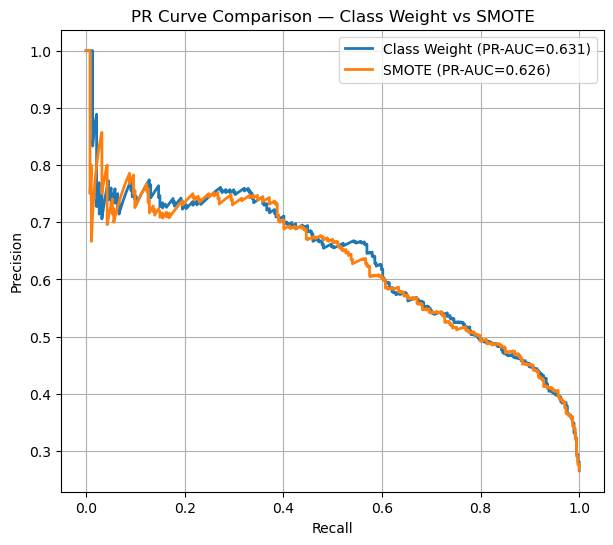

In [44]:
# Comparison between pr curve of smote and class balance

fig_comp, ax_comp = plt.subplots(figsize=(7,6))
ax_comp.plot(recall_bal, precision_bal, label=f"Class Weight (PR-AUC={pr_auc_bal:.3f})", linewidth=2)
ax_comp.plot(recall_sm, precision_sm, label=f"SMOTE (PR-AUC={pr_auc_sm:.3f})", linewidth=2)
ax_comp.set_xlabel("Recall")
ax_comp.set_ylabel("Precision")
ax_comp.set_title("PR Curve Comparison — Class Weight vs SMOTE")
ax_comp.legend()
ax_comp.grid(True)

wandb.log({"PR_Comparison": wandb.Image(fig_comp)})
plt.show()

In [48]:
# DAY-3
# model suite and nested cross validation

In [52]:
!pip install xgboost


[notice] A new release of pip is available: 25.1.1 -> 25.3


[notice] To update, run: python.exe -m pip install --upgrade pip

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [42]:
import wandb

wandb.init(
    project="Week-2",
    name="Day3_nested_cv",   
    resume="allow"                 
)


In [36]:
# Defining models and Hyperparameters
models ={
    "LogisticRegression" : LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    "RandomForest" : RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost" : XGBClassifier(eval_metric="logloss", n_estimators=200,max_depth=3,learning_rate=0.1,random_state=42)
    
}

param_grids = {
    "LogisticRegression" : {
        "C":[0.01,0.1,1,10,100],
        "penalty" : ["l2","l1"],
        "max_iter":[200,500],
        "solver": ["liblinear"]
    },
    "RandomForest" : {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        },
    "XGBoost" : {
        "max_depth":[3,5,7],
        "learning_rate":[0.01,0.1,0.2],
        "n_estimators": [200, 300, 500],
        "gamma": [0, 1, 5]
    }
}

In [37]:
# Nested CV-setup

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = {}

In [45]:
# Running nested cv for each model

for name,model in models.items():
    print(f"Running Nested CV for {name}...")
    
    grid = GridSearchCV(
        model, 
        param_grids[name], 
        scoring='roc_auc',
        cv=inner_cv, 
        n_jobs=-1, 
        verbose=0
    )
    
    # Outer CV scores
    outer_scores = cross_val_score(
        grid, 
        X_train_processed, 
        y_train, 
        scoring='roc_auc', 
        cv=outer_cv, 
        n_jobs=-1
    )
    
    # Fit grid on full training set to fetch best_params
    grid.fit(X_train_processed, y_train) 
    
    results[name] = {
        'mean_roc_auc': np.mean(outer_scores),
        'std_roc_auc': np.std(outer_scores),
        'all_scores':outer_scores,
        'best_params': grid.best_params_
    }
    
    print(f"{name}:Mean ROC-AUC={results[name]['mean_roc_auc']:.3f}, Std={results[name]['std_roc_auc']:.3f}")
    print(f"Best Params: {grid.best_params_}")
    
    # log to wandb
    

    wandb.log({
    f"{name}/Mean_ROC_AUC": results[name]["mean_roc_auc"],
    f"{name}/Std_ROC_AUC": results[name]["std_roc_auc"]
})

wandb.finish()

Running Nested CV for LogisticRegression...
LogisticRegression:Mean ROC-AUC=0.846, Std=0.013
Best Params: {'C': 10, 'max_iter': 200, 'penalty': 'l2', 'solver': 'liblinear'}
Running Nested CV for RandomForest...
RandomForest:Mean ROC-AUC=0.844, Std=0.008
Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 600}
Running Nested CV for XGBoost...
XGBoost:Mean ROC-AUC=0.849, Std=0.011
Best Params: {'gamma': 1, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}


LogisticRegression/Mean_ROC_AUC,▁
LogisticRegression/Std_ROC_AUC,▁
RandomForest/Mean_ROC_AUC,▁
RandomForest/Std_ROC_AUC,▁
XGBoost/Mean_ROC_AUC,▁
XGBoost/Std_ROC_AUC,▁
LogisticRegression/Mean_ROC_AUC,0.84604
LogisticRegression/Std_ROC_AUC,0.01279
RandomForest/Mean_ROC_AUC,0.84401
RandomForest/Std_ROC_AUC,0.00787
XGBoost/Mean_ROC_AUC,0.84861


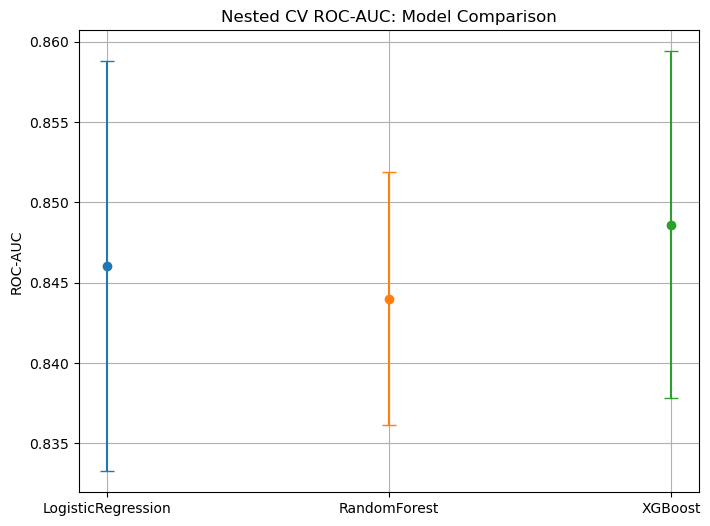

In [46]:
# Comparing Models

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for name, vals in results.items():
    plt.errorbar(name, vals["mean_roc_auc"], yerr=vals["std_roc_auc"], fmt='o', capsize=5, label=name)

plt.title("Nested CV ROC-AUC: Model Comparison")
plt.ylabel("ROC-AUC")
plt.grid(True)
plt.show()

In [38]:
# Running nested cv for each model with scoring average_precision
import wandb

wandb.init(
    project="Week-2",
    id="33d8ak29",  
    resume="allow"
)

for name,model in models.items():
    print(f"Running Nested CV for {name}...")
    
    grid = GridSearchCV(
        model, 
        param_grids[name], 
        scoring='average_precision',
        cv=inner_cv, 
        n_jobs=-1, 
        verbose=0
    )
    
    # Outer CV scores
    outer_scores = cross_val_score(
        grid, 
        X_train_processed, 
        y_train, 
        scoring='average_precision', 
        cv=outer_cv, 
        n_jobs=-1
    )
    
    # Fit grid on full training set to fetch best_params
    grid.fit(X_train_processed, y_train) 
    
    results[name] = {
        'mean_avg_precision': np.mean(outer_scores),
        'std_avg_precision': np.std(outer_scores),
        'all_scores':outer_scores,
        'best_params': grid.best_params_
    }
    
    print(f"{name}:Mean PR-AUC ={results[name]['mean_avg_precision']:.3f}, Std={results[name]['std_avg_precision']:.3f}")
    print(f"Best Params: {grid.best_params_}")
    
    # log to wandb
    

    wandb.log({
    f"{name}/Mean_PR_AUC": results[name]["mean_avg_precision"],
    f"{name}/Std_PR_AUC": results[name]["std_avg_precision"]
})

wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Running Nested CV for LogisticRegression...
LogisticRegression:Mean PR-AUC =0.658, Std=0.017
Best Params: {'C': 0.1, 'max_iter': 200, 'penalty': 'l1', 'solver': 'liblinear'}
Running Nested CV for RandomForest...
RandomForest:Mean PR-AUC =0.656, Std=0.015
Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 600}
Running Nested CV for XGBoost...
XGBoost:Mean PR-AUC =0.669, Std=0.021
Best Params: {'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


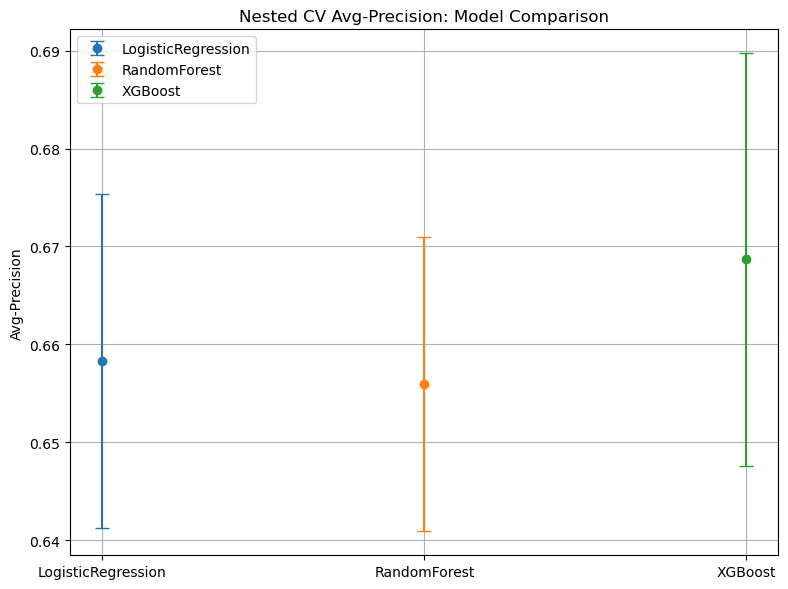

LogisticRegression/Mean_PR_AUC,▁
LogisticRegression/Std_PR_AUC,▁
RandomForest/Mean_PR_AUC,▁
RandomForest/Std_PR_AUC,▁
XGBoost/Mean_PR_AUC,▁
XGBoost/Std_PR_AUC,▁
LogisticRegression/Mean_PR_AUC,0.65831
LogisticRegression/Mean_ROC_AUC,0.84604
LogisticRegression/Std_PR_AUC,0.01709
LogisticRegression/Std_ROC_AUC,0.01279
RandomForest/Mean_PR_AUC,0.65592


In [39]:
import matplotlib.pyplot as plt
import wandb

# Create the plot
plt.figure(figsize=(8,6))
for name, vals in results.items():
    plt.errorbar(
        name, 
        vals["mean_avg_precision"], 
        yerr=vals["std_avg_precision"], 
        fmt='o', 
        capsize=5, 
        label=name
    )

plt.title("Nested CV Avg-Precision: Model Comparison")
plt.ylabel("Avg-Precision")
plt.grid(True)
plt.legend()
plt.tight_layout()

wandb.log({"PR_AUC_Model_Comparison": wandb.Image(plt)})

plt.show()

wandb.finish()


In [40]:
# Day-4

import wandb
wandb.init(project="Week-2", name="Day4_Explainability_Calibration", resume="allow")

wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [41]:
from copy import deepcopy

if "XGBoost" in globals().get("models", {}):
    xgb_model = deepcopy(models["XGBoost"])

In [42]:
# fitted in whole x_train_processed dataset

xgb_model.fit(X_train_processed, y_train)

y_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

In [44]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
y_pred = np.where(y_proba > 0.5, 1, 0)

# 2. Use y_proba (not y_prob) for probability metrics
y_prob = y_proba

# Calculate Metrics
# The 'from sklearn.metrics import ...' imports are assumed to be present.
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
# The confusion_matrix function requires two arguments: y_true and y_pred
cm = confusion_matrix(y_test, y_pred) 

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print("Confusion Matrix:\n", cm)

# -------------------------
# STEP 6: LOG TO W&B
# -------------------------
wandb.log({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1_score": f1,
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc,
})

wandb.finish()

Accuracy: 0.8013
Precision: 0.6577
Recall: 0.5241
F1-score: 0.5833
ROC-AUC: 0.8431
PR-AUC: 0.6625
Confusion Matrix:
 [[933 102]
 [178 196]]


Accuracy,▁
F1_score,▁
PR_AUC,▁
Precision,▁
ROC_AUC,▁
Recall,▁
Accuracy,0.80128
F1_score,0.58333
PR_AUC,0.66249
Precision,0.65772
ROC_AUC,0.84313


Text(0, 0.5, 'Frequency')

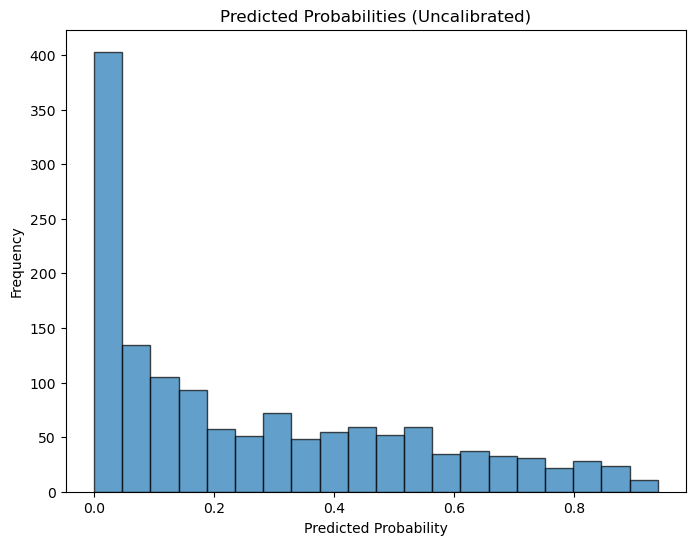

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plot using the axes object (ax)
ax.hist(y_proba, bins=20, edgecolor='black', alpha=0.7)

# 3. Apply titles and labels to the axes object
ax.set_title("Predicted Probabilities (Uncalibrated)")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Frequency")

In [50]:
# 1. Explicitly create the figure and axes
# fig is the container, ax is the plotting canvas
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Plot using the axes object (ax)
ax.hist(y_proba, bins=20, edgecolor='black', alpha=0.7)

# 3. Apply titles and labels to the axes object
ax.set_title("Predicted Probabilities (Uncalibrated)")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Frequency")

# 4. Log the specific figure object (fig) to WandB
wandb.log({"Uncalibrated_Probability_Hist": wandb.Image(fig)}) 

# 5. Explicitly close the figure object to free up memory
plt.close(fig)

In [52]:
# Brier score

from sklearn.metrics import brier_score_loss

brier_uncal = brier_score_loss(y_test, y_proba)
wandb.log({"Brier_Uncalibrated": brier_uncal})

print("Brier Score (Uncalibrated):", brier_uncal)

Brier Score (Uncalibrated): 0.13613121338029707


In [53]:
# Prob calibration (Platt/sigmoid and isotonic regression)
 
from sklearn.calibration import CalibratedClassifierCV

sigmoid_cal = CalibratedClassifierCV(xgb_model, cv=5, method="sigmoid")
isotonic_cal = CalibratedClassifierCV(xgb_model, cv=5, method="isotonic")

sigmoid_cal.fit(X_train_processed, y_train)
isotonic_cal.fit(X_train_processed, y_train)

proba_sig = sigmoid_cal.predict_proba(X_test_processed)[:, 1]
proba_iso = isotonic_cal.predict_proba(X_test_processed)[:, 1]

In [62]:
print("Brier_Sigmoid :",brier_score_loss(y_test, proba_sig))
print("Brier_Isotonic :", brier_score_loss(y_test, proba_iso))

Brier_Sigmoid : 0.13617930385917784
Brier_Isotonic : 0.1358256032009499


In [54]:
wandb.log({
    "Brier_Sigmoid": brier_score_loss(y_test, proba_sig),
    "Brier_Isotonic": brier_score_loss(y_test, proba_iso),
})

In [57]:
from sklearn.calibration import calibration_curve

def calculate_ece(y_true, y_prob, n_bins=10):
    """
    Calculates the Expected Calibration Error (ECE).
    """
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    
    # Compute the number of samples in each non-empty bin
    bin_counts = np.histogram(y_prob, bins=np.linspace(0,1,len(prob_true)+1))[0]
    bin_weights = bin_counts / np.sum(bin_counts)

    ece = np.sum(np.abs(prob_true - prob_pred) * bin_weights)
    return ece

In [58]:
ece_uncal = calculate_ece(y_test, y_proba)
ece_sig = calculate_ece(y_test, proba_sig)
ece_iso = calculate_ece(y_test, proba_iso)

wandb.log({
    "ECE_Uncalibrated": ece_uncal,
    "ECE_Sigmoid": ece_sig,
    "ECE_Isotonic": ece_iso
})

In [68]:
print("ECE_Uncalibrated :",ece_uncal, "ECE_Sigmoid/Platt :", ece_sig, "ECE_Isotonic:",ece_iso)

ECE_Uncalibrated : 0.023144321646039002 ECE_Sigmoid/Platt : 0.03248187487298467 ECE_Isotonic: 0.023845421370598727


Text(0.5, 1.0, 'Calibration Curves (Reliability Diagram)')

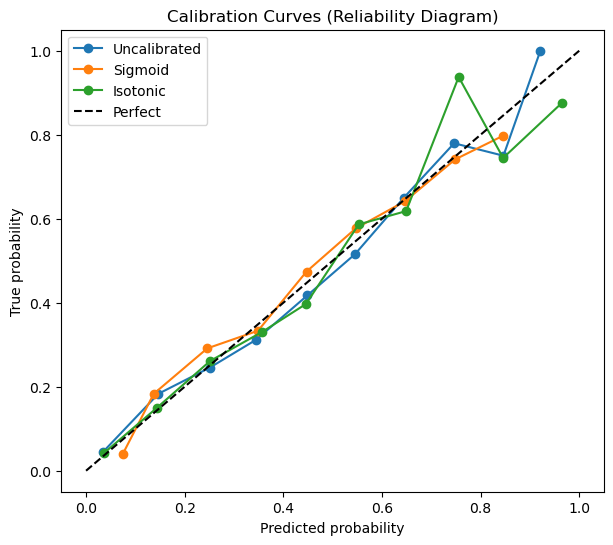

In [70]:
fig, ax = plt.subplots(figsize=(7, 6))

for proba, name in [
    (y_proba, "Uncalibrated"),
    (proba_sig, "Sigmoid"),
    (proba_iso, "Isotonic")
]:
    # Use the calibration_curve function
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
    
    #  Plot on the axes object (ax)
    ax.plot(prob_pred, prob_true, marker="o", label=name)

#  Plot the perfect line on the axes object
ax.plot([0, 1], [0, 1], "k--", label="Perfect")

#  Set labels, title, and legend using the axes object
ax.set_xlabel("Predicted probability")
ax.set_ylabel("True probability")
ax.legend()
ax.set_title("Calibration Curves (Reliability Diagram)")

In [69]:
#  Explicitly create the figure and axes
fig, ax = plt.subplots(figsize=(7, 6))

for proba, name in [
    (y_proba, "Uncalibrated"),
    (proba_sig, "Sigmoid"),
    (proba_iso, "Isotonic")
]:
    # Use the calibration_curve function (from sklearn.calibration)
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
    
    # Plot on the axes object (ax)
    ax.plot(prob_pred, prob_true, marker="o", label=name)

# Plot the perfect line on the axes object
ax.plot([0, 1], [0, 1], "k--", label="Perfect")

# Set labels, title, and legend using the axes object
ax.set_xlabel("Predicted probability")
ax.set_ylabel("True probability")
ax.legend()
ax.set_title("Calibration Curves (Reliability Diagram)")

#  Log the specific figure object (fig) to WandB
wandb.log({"Calibration_Curves": wandb.Image(fig)}) 

plt.close(fig)

In [3]:
#!pip install -r requirements.txt

In [52]:
#print(np.__version__)

In [57]:
import sys
!{sys.executable} -m pip install shap==0.41.0
#!pip install shap

  Attempting uninstall: shap
    Found existing installation: shap 0.44.0
    Uninstalling shap-0.44.0:
      Successfully uninstalled shap-0.44.0


  You can safely remove it manually.


In [60]:
!pip install numpy==1.23.5
!pip install xgboost==1.7.6
!pip install shap==0.44
!pip install scikit-learn pandas
!pip install imbalanced-learn

  Using cached numpy-1.23.5-cp310-cp310-win_amd64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp310-cp310-win_amd64.whl (14.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.14.0 requires numpy<3,>=1.25.2, but you have numpy 1.23.5 which is incompatible.


  Using cached shap-0.44.0-cp310-cp310-win_amd64.whl.metadata (24 kB)
Using cached shap-0.44.0-cp310-cp310-win_amd64.whl (447 kB)
  Attempting uninstall: shap
    Found existing installation: shap 0.41.0
    Uninstalling shap-0.41.0:
      Successfully uninstalled shap-0.41.0


  You can safely remove it manually.


  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5


In [60]:
import shap

# For tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb_model,X_train_processed)
shap_values = explainer(X_test_processed)

[15:04:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


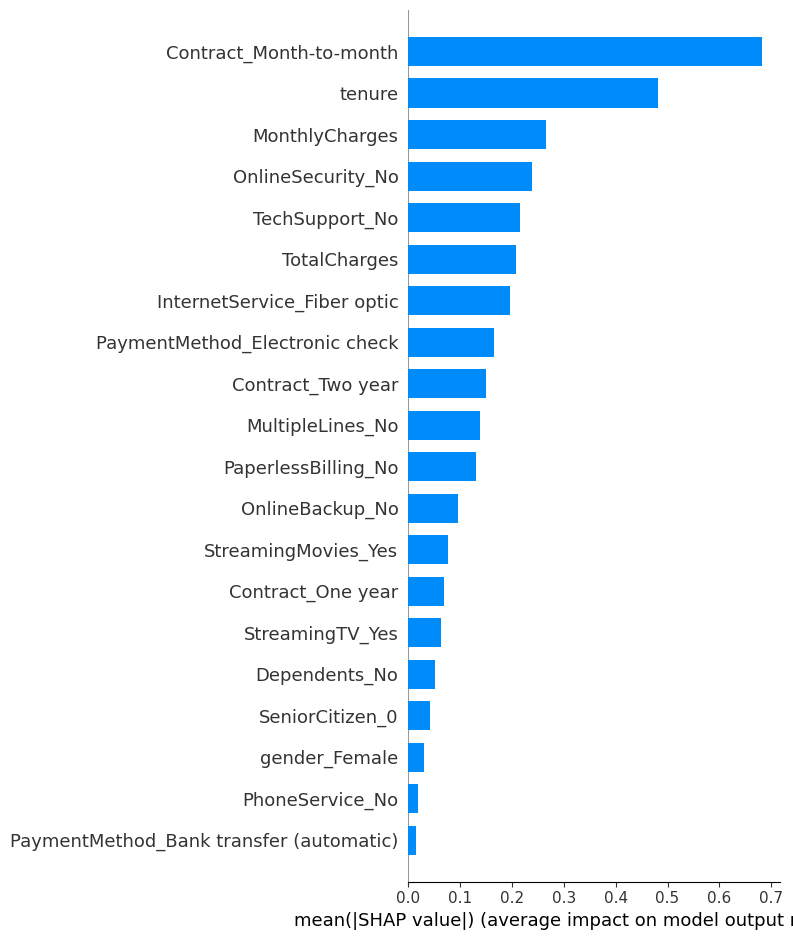

In [51]:
shap.summary_plot(shap_values, X_test_processed, plot_type="bar")

In [68]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split


# --- Example Setup (if you need to run this code independently) ---
shap.initjs() 

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)


# Corrected way to plot the force plot for the first instance:
print("Generating force plot for the first instance:")

first_instance_features = X_test_processed.iloc[0]


first_instance_shap_values = shap_values[0]
if isinstance(shap_values, list) and isinstance(shap_values[0], shap.Explanation):
    first_instance_shap_values_array = shap_values[0].values
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2:
    first_instance_shap_values_array = shap_values[0]
else:
    raise TypeError("Unexpected type or shape for shap_values. Please check its structure.")


shap.force_plot(
    explainer.expected_value,
    first_instance_shap_values_array, # Pass the SHAP values (1D array) for the first instance
    first_instance_features         # Pass the feature values (pandas Series) for the first instance
    # features_names is not strictly necessary here because first_instance_features is a pandas Series
    # and already contains the column names.
)

[15:19:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


Generating force plot for the first instance:


[12:34:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0cec3277c4d9d0165-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


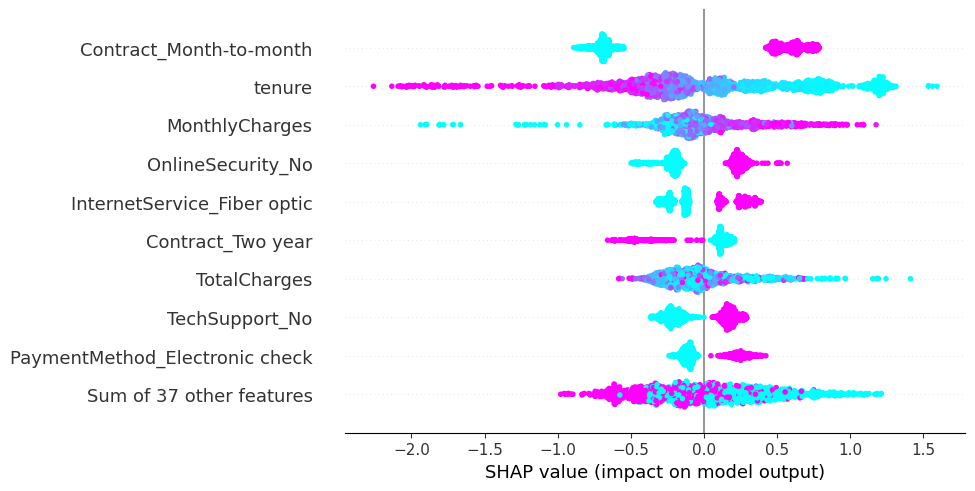

In [67]:
# Compute SHAP values
explainer = shap.Explainer(xgb_model, X_test_processed)
shap_values = explainer(X_test_processed)

# Disable color bar to avoid the error
shap.plots.beeswarm(shap_values, color="cool", color_bar=False)

In [65]:
X_train_processed.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female',
       'gender_Male', 'SeniorCitizen_0', 'SeniorCitizen_1', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       '

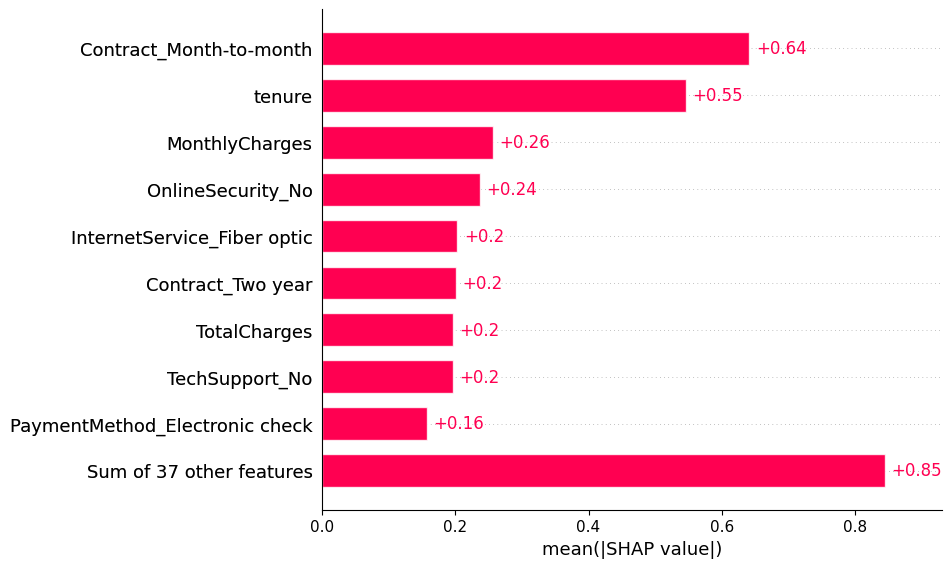

In [69]:
shap.plots.bar(shap_values.abs.mean(0))

In [54]:
shap.force_plot(
    expected_value,
    shap_values[misclassified],
    features_display[misclassified],
    link="logit",
    matplotlib=True,
)

NameError: name 'shap' is not defined

In [47]:
wandb.log({
    "Final/Brier_Uncalibrated": brier_uncal,
    "Final/Brier_Sigmoid": brier_score_loss(y_test, proba_sig),
    "Final/Brier_Isotonic": brier_score_loss(y_test, proba_iso),
    "Final/ECE_Uncalibrated": ece_uncal,
    "Final/ECE_Sigmoid": ece_sig,
    "Final/ECE_Isotonic": ece_iso
})

In [48]:
#!pip install wandb

In [49]:
# !pip uninstall wandb -y
# !pip install wandb --upgrade

In [39]:
import wandb

wandb.init(
    project="Week-2",
    name="Day4_Threshold_vs_Cost",
    resume="allow"
)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Minimum total cost: 59600
Best threshold: 0.160


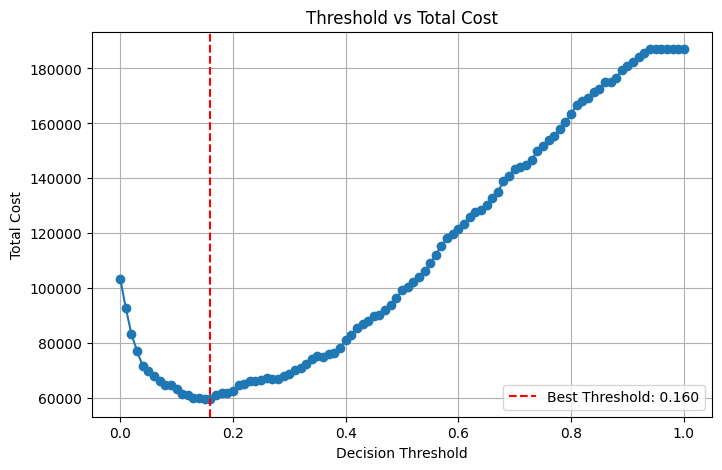

In [48]:
import wandb
import numpy as np
import matplotlib.pyplot as plt

# Real labels and predicted probabilities
y_true = y_test  # your actual test labels
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]  # predicted probabilities for positive class

# Costs
cost_fn = 500  # False negative
cost_fp = 100  # False positive

# Thresholds to evaluate
thresholds = np.linspace(0, 1, 101)
total_costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    fn = np.sum((y_pred == 0) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    total_cost = fn * cost_fn + fp * cost_fp
    total_costs.append(total_cost)

# Find threshold with minimum total cost
min_idx = np.argmin(total_costs)
best_threshold = thresholds[min_idx]
min_cost = total_costs[min_idx]

print(f"Minimum total cost: {min_cost}")
print(f"Best threshold: {best_threshold:.3f}")

# Optionally, highlight it on the plot
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(thresholds, total_costs, marker='o')
ax.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold: {best_threshold:.3f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Total Cost")
ax.set_title("Threshold vs Total Cost")
ax.grid(True)
ax.legend()

# Log plot to W&B
# wandb.log({"Threshold_vs_Cost": wandb.Image(fig)})

plt.show()


In [51]:
y_pred_05 = (y_prob >= 0.5).astype(int)
fn_05 = np.sum((y_pred_05 == 0) & (y_true == 1))
fp_05 = np.sum((y_pred_05 == 1) & (y_true == 0))
cost_05 = fn_05 * cost_fn + fp_05 * cost_fp
print("Cost at threshold 0.5:", cost_05)

Cost at threshold 0.5: 99200


In [53]:
y_pred_all_neg = np.zeros_like(y_true)  # predict all 0
fn_neg = np.sum((y_pred_all_neg == 0) & (y_true == 1))
fp_neg = np.sum((y_pred_all_neg == 1) & (y_true == 0))
cost_all_neg = fn_neg * cost_fn + fp_neg * cost_fp
print("Cost for all-negative baseline:", cost_all_neg)

Cost for all-negative baseline: 187000


In [49]:
import json
with open("threshold.json", "w") as f:
    json.dump({"threshold": float(best_threshold), "expected_cost": float(min_cost)}, f)

In [50]:
fig.savefig("plot.png")

In [58]:
!pip freeze > requirements.txt

In [68]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [70]:
# Day-5

In [72]:
X_test_df = X_test.copy() if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test_processed)
X_test_df['y_true'] = y_test
X_test_df['y_prob'] = xgb_model.predict_proba(X_test_processed)[:, 1]

# check the first rows
X_test_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,y_true,y_prob
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0.012494
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,0.835819
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0.071803
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0.349043
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0.005210


In [73]:
import wandb

wandb.init(
    project="Week-2",
    name="Day5_Slicing_metrics",
    resume="allow"
)

In [75]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Example: create tenure groups if needed
bins = [0, 12, 24, 100]  # months
labels = ['0-12', '12-24', '24+']
X_test_df['tenure_group'] = pd.cut(X_test_df['tenure'], bins=bins, labels=labels)

# Define slice columns
slice_columns = ['Contract', 'tenure_group', 'PaymentMethod']

# Compute metrics for each slice
for col in slice_columns:
    for group in X_test_df[col].unique():
        slice_df = X_test_df[X_test_df[col] == group]
        if len(slice_df) == 0:
            continue
        roc = roc_auc_score(slice_df['y_true'], slice_df['y_prob'])
        pr_auc = average_precision_score(slice_df['y_true'], slice_df['y_prob'])
        print(f"{col} = {group} | ROC-AUC = {roc:.3f} | PR-AUC = {pr_auc:.3f}")
        
        # Log to W&B
        wandb.log({
            f"Fairness/ROC_AUC_{col}_{group}": roc,
            f"Fairness/PR_AUC_{col}_{group}": pr_auc
        })

Contract = Two year | ROC-AUC = 0.724 | PR-AUC = 0.075
Contract = Month-to-month | ROC-AUC = 0.755 | PR-AUC = 0.699
Contract = One year | ROC-AUC = 0.724 | PR-AUC = 0.256
tenure_group = 24+ | ROC-AUC = 0.825 | PR-AUC = 0.442
tenure_group = 0-12 | ROC-AUC = 0.767 | PR-AUC = 0.750
tenure_group = 12-24 | ROC-AUC = 0.801 | PR-AUC = 0.599
PaymentMethod = Credit card (automatic) | ROC-AUC = 0.853 | PR-AUC = 0.566
PaymentMethod = Electronic check | ROC-AUC = 0.782 | PR-AUC = 0.733
PaymentMethod = Bank transfer (automatic) | ROC-AUC = 0.867 | PR-AUC = 0.643
PaymentMethod = Mailed check | ROC-AUC = 0.816 | PR-AUC = 0.508


 # GOOD segments (both numbers high):

 Month-to-month contracts: Model works great here (0.755, 0.699)
 
 New customers (0-12 months): Best performance (0.767, 0.750)
 
 Electronic check payments: Reliable predictions (0.782, 0.733)

# PROBLEM segments (big gap between numbers):

Two-year contracts: ROC ok (0.724) but PR terrible (0.075)

Model says churn but almost always wrong because of false positives

Mailed check payments: ROC decent (0.816) but PR low (0.508)

Same problem: too many wrong "churn" predictions

In [ ]:
# What to Do in Business ?
# ans: Send retention offers to:Month-to-month customers and New customers (<12 months) & Electronic check users

# Don't waste money on:
# Two-year contract customers (model predicts churn wrong 92% of time)
# Mailed check customers (wasteful false positives)

In [76]:
import pickle

# Save as pickle
artifact_path = "xgboost_model_day5.pkl"
with open(artifact_path, "wb") as f:
    pickle.dump(xgb_model,f)

# Log artifact to W&B
artifact = wandb.Artifact("xgboost_model", type="model")
artifact.add_file(artifact_path)
wandb.log_artifact(artifact)

print("Model artifact saved and logged to W&B.")

Model artifact saved and logged to W&B.


In [43]:
!pip install --upgrade mapie

In [47]:
import wandb
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from mapie.classification import SplitConformalClassifier

In [50]:
wandb.init(
    project="Week-2",
    name= "Day_5_Conformal_Prediction",
    config={
        "model": "XGBClassifier",
        "conformal_method": "split",
        "confidence_level": 0.9
    }
)
config = wandb.config

wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.base import clone

alpha = 0.1  # 90% confidence intervals

# ------------ STEP 1: CREATE CALIBRATION SPLIT ------------
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# ------------ STEP 2: TRAIN MODEL ON TRAIN SPLIT ------------
model_cp = clone(xgb_model)
model_cp.fit(X_tr, y_tr)

# ------------ STEP 3: GET PROBABILITIES ON CALIBRATION SET ------------
cal_probs = model_cp.predict_proba(X_cal)[:, 1]

# ------------ STEP 4: COMPUTE CONFORMITY SCORES ------------
# Score = |p - y|
scores = np.abs(cal_probs - y_cal)

# α-quantile of conformity distribution
q_hat = np.quantile(scores, 1 - alpha)

print("Conformal Quantile (q_hat):", q_hat)

# ------------ STEP 5: APPLY TO TEST SET ------------
test_probs = model_cp.predict_proba(X_test_processed)[:, 1]

lower_prob = np.maximum(test_probs - q_hat, 0)
upper_prob = np.minimum(test_probs + q_hat, 1)

# Confidence = 1 - width
confidence = 1 - (upper_prob - lower_prob)

# ------------ STEP 6: BUILD RESULT DF ------------
df_conf = pd.DataFrame({
    "y_true": y_test,
    "p_hat": test_probs,
    "lower_prob": lower_prob,
    "upper_prob": upper_prob,
    "confidence": confidence
})

print(df_conf.sample(10))

# df_conf.to_csv("conformal_prob_intervals.csv", index=False)

Conformal Quantile (q_hat): 0.6532145023345947
      y_true     p_hat  lower_prob  upper_prob  confidence
779        1  0.468454    0.000000    1.000000    0.000000
346        1  0.725453    0.072239    1.000000    0.072239
2179       0  0.034597    0.000000    0.687812    0.312188
2221       0  0.003639    0.000000    0.656853    0.343147
7033       0  0.225809    0.000000    0.879024    0.120976
6783       0  0.018095    0.000000    0.671309    0.328691
6388       1  0.351534    0.000000    1.000000    0.000000
1783       1  0.758471    0.105257    1.000000    0.105257
5691       0  0.034075    0.000000    0.687289    0.312711
2954       1  0.558479    0.000000    1.000000    0.000000


In [53]:
# 1. Log overall conformal quantile
wandb.log({"Conformal_Quantile_qhat": float(q_hat)})

# 2. Log mean interval width (uncertainty)
mean_width = (df_conf["upper_prob"] - df_conf["lower_prob"]).mean()
wandb.log({"Mean_Interval_Width": mean_width})

# 3. Log mean confidence score
mean_conf = df_conf["confidence"].mean()
wandb.log({"Mean_Confidence": mean_conf})

wandb.finish()

Conformal_Quantile_qhat,▁▁
Mean_Confidence,▁
Mean_Interval_Width,▁
Conformal_Quantile_qhat,0.65321
Mean_Confidence,0.17503
Mean_Interval_Width,0.82497


In [45]:
# Time Based Split
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
import xgboost as xgb
import wandb

# -------------------------
# Initialize W&B
# -------------------------
wandb.init(project="Week-2", name="Tenure_Based_Split", resume="allow")

# -------------------------
# STEP 1: SORT DATA BY TENURE
# -------------------------
X_sorted = X_train_processed.sort_values(by="tenure")
y_sorted = y_train.loc[X_sorted.index]

# -------------------------
# STEP 2: TENURE-BASED SPLIT (80% train, 20% test)
# -------------------------
split_idx = int(0.8 * len(X_sorted))
X_tr = X_sorted.iloc[:split_idx]
y_tr = y_sorted.iloc[:split_idx]
X_te = X_sorted.iloc[split_idx:]
y_te = y_sorted.iloc[split_idx:]

# -------------------------
# STEP 3: TRAIN MODEL
# -------------------------
model = clone(xgb_model)  # reuse your previously trained hyperparameters
model.fit(X_tr, y_tr)

# -------------------------
# STEP 4: PREDICTIONS
# -------------------------
y_pred = model.predict(X_te)
y_prob = model.predict_proba(X_te)[:, 1]  # probability for positive class

# -------------------------
# STEP 5: EVALUATE METRICS
# -------------------------
acc = accuracy_score(y_te, y_pred)
prec = precision_score(y_te, y_pred)
rec = recall_score(y_te, y_pred)
f1 = f1_score(y_te, y_pred)
roc_auc = roc_auc_score(y_te, y_prob)         # probabilities
pr_auc = average_precision_score(y_te, y_prob) # probabilities
cm = confusion_matrix(y_te, y_pred)            # predicted labels

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print("Confusion Matrix:\n", cm)

# -------------------------
# STEP 6: LOG TO W&B
# -------------------------
wandb.log({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1_score": f1,
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc,
})

wandb.finish()

Accuracy: 0.9228
Precision: 0.3333
Recall: 0.1299
F1-score: 0.1869
ROC-AUC: 0.7807
PR-AUC: 0.2242
Confusion Matrix:
 [[1030   20]
 [  67   10]]


Accuracy,▁
F1_score,▁
PR_AUC,▁
Precision,▁
ROC_AUC,▁
Recall,▁
Accuracy,0.9228
F1_score,0.18692
PR_AUC,0.22415
Precision,0.33333
ROC_AUC,0.78072
